<a href="https://colab.research.google.com/github/flaviocorrea-usa/Repo_FlavioCorrea/blob/main/10_HomographyProjections_16Apr2026_run1127PM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/flaviocorrea-usa/Repo_FlavioCorrea/blob/main/10_HomographyProjections_16Apr2026_run0250PM.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CSCI E-25      
## Homography and Projection
### Steve Elston

#### Student: Flavio Correa

## Introduction   

Transformation or projection of images is a fundamental and essential method in computer vision. Many CV applications, such as image stitching and stereo vision, require projection methods.

In these exercises our primary focus is on projection using the extrinsic matrix. You will apply three types of commonly used extrinsic and one intrinsic transformation to an image:    
1. **Euclidean**, rotation and translation.
2. **Similarity**, rotation, translation and scale.
3. **Affine**,  rotation, translation, scale and shear.    
4. **Projective**, a general transformation for camera pose.   
5. **Intrinsic camera parameters**, focal length.

Before starting the exercises execute the code in the cell below to import the required packages.

In [1]:
import skimage
from skimage import data
from skimage.filters.rank import equalize
import skimage.filters as skfilters
import skimage.morphology as morphology
import skimage.transform as transform
from skimage.color import rgb2gray
from skimage import exposure
from skimage.draw import circle_perimeter, polygon_perimeter
from PIL import Image
import numpy as np
import math
import matplotlib.pyplot as plt
%matplotlib inline

## Load and Prepare the Image

For these exercises you will work with a gray scale image. Execute the code in the cell below to load the image and display it.

Image size = (512, 512)


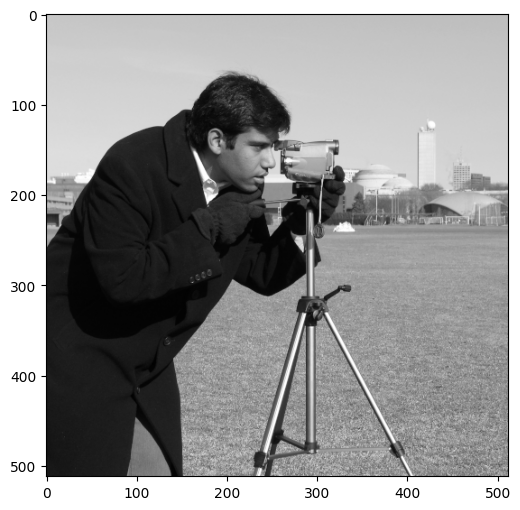

In [2]:
def plot_grayscale(img, h=6, ax=None):
    if ax is None:
        plt.figure(figsize=(h, h))
        _=plt.imshow(img, cmap=plt.get_cmap('gray'))
    else:
         _=ax_i.imshow(img, cmap=plt.get_cmap('gray'))


camera_image = data.camera()
print('Image size = ' + str(camera_image.shape))
plot_grayscale(camera_image)
plt.show()

To make the process of visualizing the transformations of image easier a dark margin will be added to the image. Execute the code in the cell below to place the image on the background and to display the result.   

Shape of the background = (1024, 1024)


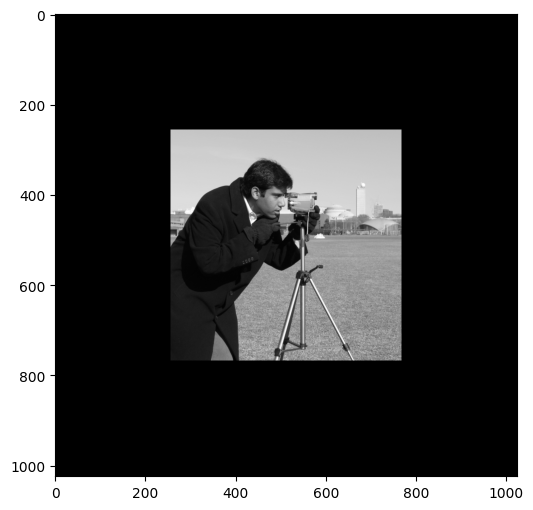

In [3]:
half_margin = 256
background = np.zeros((camera_image.shape[0] + 2*half_margin, camera_image.shape[1] + 2*half_margin)).astype('int')
print('Shape of the background = ' + str(background.shape))

camera_image_background = background
#camera_image_background[2*half_margin:camera_image_background.shape[0], 0:camera_image_background.shape[1]-2*half_margin] = camera_image
camera_image_background[half_margin:camera_image_background.shape[0] - half_margin, half_margin:camera_image_background.shape[1]-half_margin] = camera_image
plot_grayscale(camera_image_background)
plt.show()

> **Note:** Unless otherwise specified, use this gray scale image of the photographer where specified in the following exercises.

To demonstrate these principles execute the code in the cell below to create an image with some simple geometric shapes.

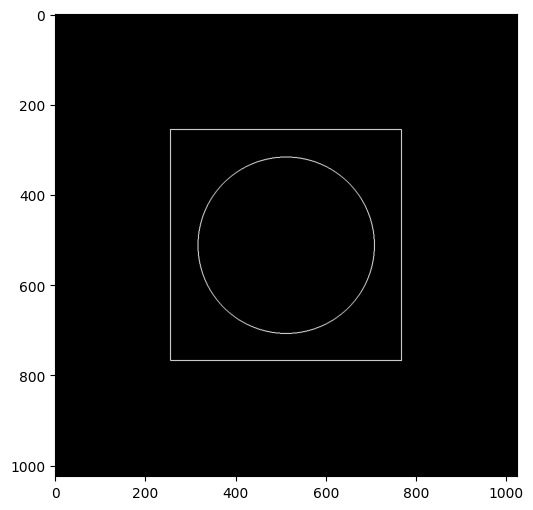

In [4]:
## Create a blank image
synthetic_image = np.zeros((1024, 1024), dtype=np.uint8)\
## Add a circle
rr, cc = circle_perimeter(512, 512, 196)
synthetic_image[rr, cc] = 1
rr, cc = circle_perimeter(512, 512, 195)
synthetic_image[rr, cc] = 1
## Add a square
rr, cc = polygon_perimeter([256, 256, 768, 768], [256, 768, 768, 256])
synthetic_image[rr, cc] = 1
rr, cc = polygon_perimeter([255, 255, 767, 767], [255, 767, 767, 255])
synthetic_image[rr, cc] = 1
## Display the results
plot_grayscale(synthetic_image)
plt.show()

## Euclidean Transformation

The Euclidean transformation involves only rotation and translation. The shape of objects is preserved by the Euclidean transformation.    

The code in the cell below applies both translation and rotation to the geometric shape image. The Execute this code and examine the results.  

> **Exercise 10-1:** You will now apply the Euclidean transformation to the synthetic image and then the real image. This operation involves applying a rotation and translation to the image plane. Follow the numbered steps.
> 1. To start, you will complete the function in the cell below. The function will return a $3 x 3$ Numpy array for the Euclidean transform.

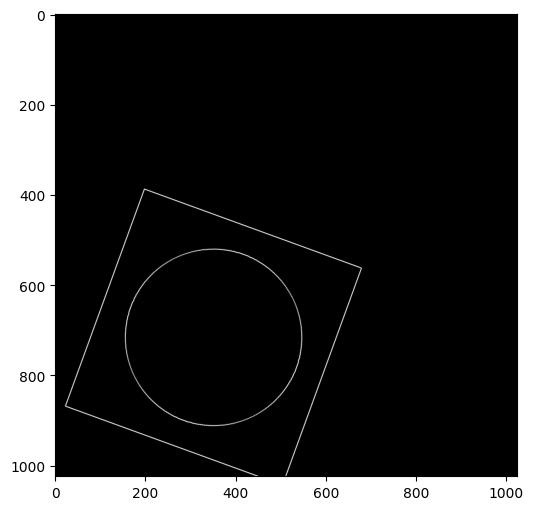

In [5]:
## Put your code below
def euclidean(theta, translation):
  tx, ty = translation
  c = np.cos(theta)
  s = np.sin(theta)
  E = np.array([[ c, -s,  tx], [ s,  c,  ty],[ 0,  0,   1]], dtype=float)
  return E

theta = np.deg2rad(20)
translation = (45, 60)

E = euclidean(theta, translation)

# Apply to the synthetic image
from skimage.transform import warp
transformed = warp(synthetic_image, np.linalg.inv(E), output_shape=synthetic_image.shape)

plot_grayscale(transformed)
plt.show()


> 2. Execute the code in the cell below.
>
> **Important Note:** Notice that the second argument of the warp functuion is an *inverse map*. This convention makes sense for many CV tasks, such as image stitching and stereo vision, where one must apply the inverse transform to an image to recify it with the coordinates of a reference image. This means that some values of transform matrix will need to be modified to account for the way the transformaiton in applied by this function. Which transformation variables using an inverse affects depends on which side of the image plane the observer is viewing. For these exercises, we assome the observer is looking at the image plane from the side with the images in the scene. We maintain the right-handed coordinate system convention from this point of view.     

[[  0.981   0.195 -99.886]
 [ -0.195   0.981  99.886]
 [  0.      0.      1.   ]]
[[   0.924   -0.383  195.934]
 [   0.383    0.924 -195.934]
 [   0.       0.       1.   ]]


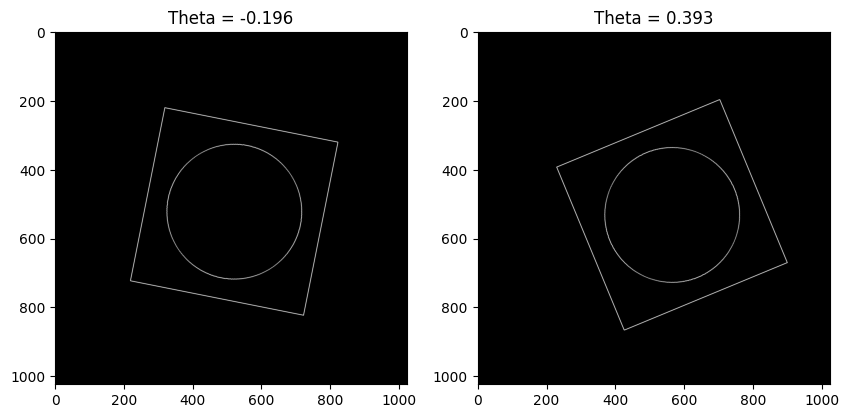

In [6]:

n_pix = 512.0
_, ax = plt.subplots(1,2, figsize=(10, 5))
ax = ax.flatten()
theta = [-math.pi/16.0, math.pi/8.0]
for i,ax_i in enumerate(ax):
    translation = np.array([n_pix * math.sin(theta[i]), -n_pix * math.sin(theta[i])])
    transform_matrix = euclidean(theta[i], translation)
    print(np.round(transform_matrix, 3))
    _=plot_grayscale(transform.warp(synthetic_image, transform_matrix), ax=ax_i)
    ax_i.set_title('Theta = ' + str(np.round(theta[i], 3)))
plt.show()

> Answer the following questions:    
> Q1. Does the roation angle appear correct for both case and why given the right-handed coordinate system?     
> Q2. Which aspect? of the rectangle shape are preseved by this transform? In other words, why is the Euclidean transformation consider ridgid body motion.             
> Q3. Explain why the x and y translations computed above keep shapes at the center of the images in the right-handed coordinate system. Pay attention to the sign of the translation compoenents, keeping in mind the origin of the coordiate system is at the upper left of the image.        

> **Answers:**     
> Q1.   Yes, the rotation angle appears correct for both cases because as the z axis is going out of the image towards us, the positive rotation would be counterclockwise, and the negative will go clockwise. As teh y-axis is going down (as the reference is the point on the top-left corner of the image), then the rotation has this adjusted, and the negative moves counterclockswise and the posoitive is clockwise as we intuitively expect.
>
> Q2.    All the aspects of the rectangle shape are preserved, like the angles, the parallelism in the lines of the rectangle and the circle inside are all preserved. There is no "distortion" cause by any perspective, as we are just rotating the figure using the angle theta.
>
> Q3.    The idea is that the center is calculated from the top-left corner of the image. In that sense, when rotating, we could expect that the center would move away from the original position, as the rotation would be done from the reference pont perspective (top-left corner). However, the code: [n_pix * math.sin(theta[i]] for the x-translation, and a similar [-n_pix * math.sin(theta[i])] for the y-translation corrected the center and avoided the image to float around the space.

> 3. Apply the second transformation matrix to the image of the photographer and display the result.  

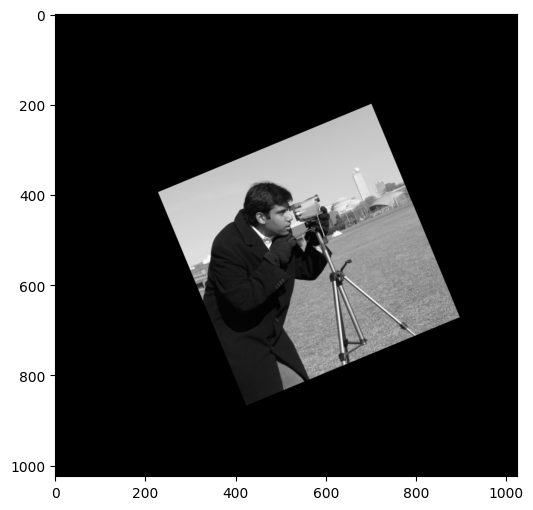

In [7]:
_=plot_grayscale(transform.warp(camera_image_background, transform_matrix))
plt.show()

> Q4. Is the transformation of the photographer image consistent with the transformation of the geometric shape image and is this expected?     

> **Answer:**   Yes, the transformation of the photographer consistent with the transformation of the geometric shape, as it rotates towards the same orientation, also shifted using the translation as mentioned in the previous question, and there is no distortion of the image,  keeping the parallel lines, angles and dimensions.

> 4. Finally, you can check your transformation matrix by using the [skimage.transform.EuclideanTransform](https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.EuclideanTransform) function, using the rotation angle and translation vector for the second example. Compute and display the transformation matrix.   

In [8]:
## Put your code below
ski_euclidean = transform.EuclideanTransform(rotation=theta[1],
                                             translation=translation)

print("Our euclidean() matrix:")
print(np.round(transform_matrix, 6))
print("\nskimage EuclideanTransform matrix:")
print(np.round(ski_euclidean.params, 6))

print("\nDifference:")
print(np.round(transform_matrix - ski_euclidean.params, 10))


Our euclidean() matrix:
[[   0.92388    -0.382683  195.933917]
 [   0.382683    0.92388  -195.933917]
 [   0.          0.          1.      ]]

skimage EuclideanTransform matrix:
[[   0.92388    -0.382683  195.933917]
 [   0.382683    0.92388  -195.933917]
 [   0.          0.          1.      ]]

Difference:
[[0. 0. 0.]
 [0. 0. 0.]
 [0. 0. 0.]]


> Q5. Compare the transformation matrix comptued with the function you created with the one created with the Scikit image functuion. Are they identical as is this expected?    
> **End of exercise.**

> **Answer:**     As shown in the cell output above, the transforamtion matrices are identical as expected (also evindenced by the difference matrix equals to zero). My understanding is that both the transformation and the ski_euclidean = transform.EuclideanTransform() apply the same Euclidean transformation, ensuring that the images are identical, and their matrices are equal.

Here is an additonal experiment with the translation vector.

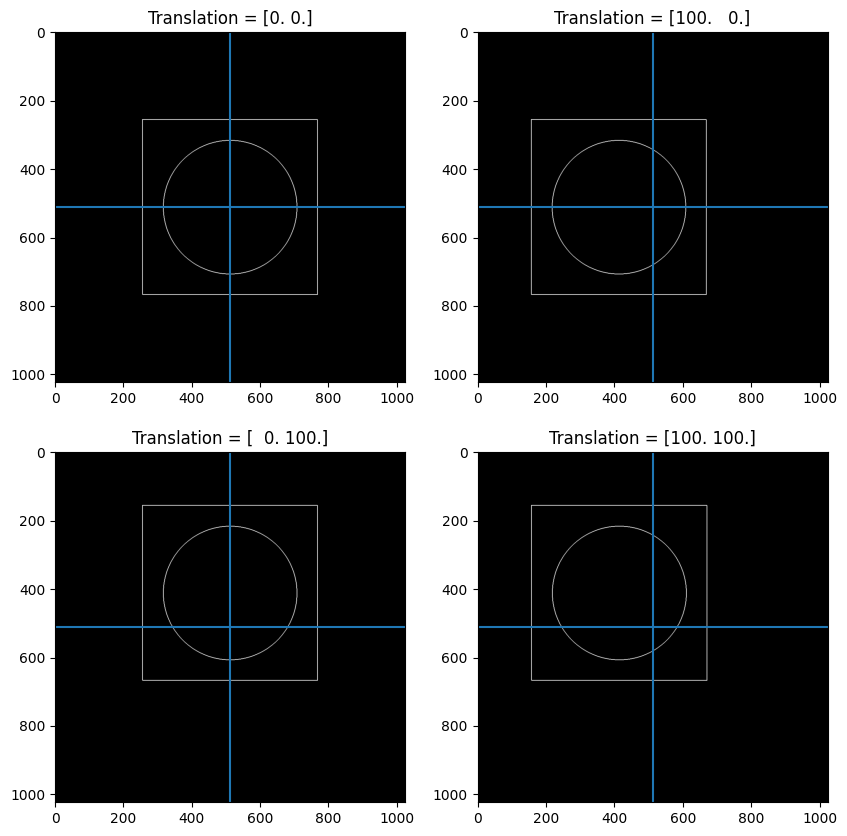

In [9]:
n_pix = 512.0
_, ax = plt.subplots(2,2, figsize=(10, 10))
ax = ax.flatten()
theta = [0.0,0.0,0.0,0.0]
translation_array = np.array([[0.0,0.0],
              [100.0,0.0],
              [0.0,100.0],
              [100.0,100.0]])
for i,ax_i in enumerate(ax):
    translation = translation_array[i,:]
    transform_matrix = euclidean(theta[i], translation)
    _=plot_grayscale(transform.warp(synthetic_image, transform_matrix), ax=ax_i)
    ax_i.axvline(x=n_pix)
    ax_i.axhline(y=n_pix)
    ax_i.set_title('Translation = ' + str(np.round(translation, 3)))
plt.show()

## Similarity Transform

You will now extend the generality of the transformation by adding a change of scale. A similarity transformation can perform rotation, translation as well as scale. Like the Euclidean transform, the similarity transform parallel lines and angles.   

> **Exercise 10-2:**  You will now do the following to explore the properties of the similarity transform:
> 1. Complete the `similarity`function in the cell below to compute and return the following.      
>    a. Use the `euclidean` function you created in Exercise 1 to compute the $3 x 3$ Euclidiean transformation matrix.       
>    b. Create a $3 x 3$ scale transform as a Numpy array with the **inverse** x axis and y axis scale factors as the first two diagonal elements, 1.0 as the final diagonal element, and 0s everywhere else. The inverse of the scale is required since the [skimage.transform.warp](https://scikit-image.org/docs/stable/api/skimage.transform.html#skimage.transform.warp) function expects the inverse.
>    c. Use [numpy.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) function to multiply the Euclidean matrix (second argument) by the scale matrix (first argument). The order of the multiplication will mater.
> 2. Execute the code.

[[ 9.240e-01 -3.830e-01  0.000e+00]
 [ 7.650e-01  1.848e+00 -5.120e+02]
 [ 0.000e+00  0.000e+00  1.000e+00]]
[[   1.848   -0.765    0.   ]
 [   0.383    0.924 -256.   ]
 [   0.       0.       1.   ]]


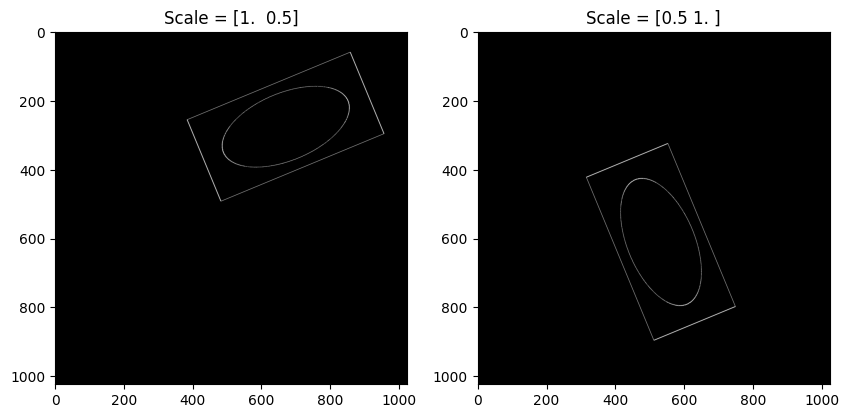

In [10]:
## Put your code below
def similarity(theta, translation, scale):
  E = euclidean(theta, translation)
  S = np.array([[1.0 / scale[0], 0.0, 0.0],
   [0.0,1.0/scale[1], 0.0],[0.0, 0.0, 1.0]], dtype=float)
  return np.dot(S, E)

theta = math.pi/8

_, ax = plt.subplots(1,2, figsize=(10, 5))
ax = ax.flatten()
theta = math.pi/8.0
scale = np.array([[1.0,0.5],
                 [0.5, 1.0]])
for i,ax_i in enumerate(ax):
    transform_matrix = similarity(theta, [0, -256], scale[i,:])
    print(np.round(transform_matrix,3))
    _=plot_grayscale(transform.warp(synthetic_image, transform_matrix), ax=ax_i)
    ax_i.set_title('Scale = ' + str(np.round(scale[i,:], 3)))
plt.show()

> Now, answer the following questions:     
> Q1: Notice the x and y axis scaling of the geometric shapes. Are the images as expected given the two scalings and why?    
> Q2: What properties of the rectangle are preseved by these transformations?      
> Q3: Noice that y translation has changed for the first case. How can you expalain this change, keeping in mind that we are computing the inverse transform?     

> **Answers:**     
> Q1:    Yes, the images look correct, considering the x and y scaling. As y is 0.5 of the scale, it means it was compressed to half, which made the image "shorter" in the y-axis. The same happened to the x-axis for the second image (to the right), as the x-axis was compressed in half and got "skinnier" in the x-axis. The looks of the two images looks like it is "flattened" or "compressed" in the axis of the scale (sorry, really difficult to use good words to describe the image here...)
>
> Q2:    Well, the angles and the parallelism of the lines are preserved. It does not preserve the distance of the vertices, that are reduced according to the scale.
>
> Q3:     To explain that the translation changes for the first case, I guess it is a factor of the scale. If the scale is done using 1/scale, then the translation gets 1/05, which is 2, so the translation apparently doubles to keep the image where it should be.

> 4. Apply the second transformation matrix to the image of the photographer and display the result.  

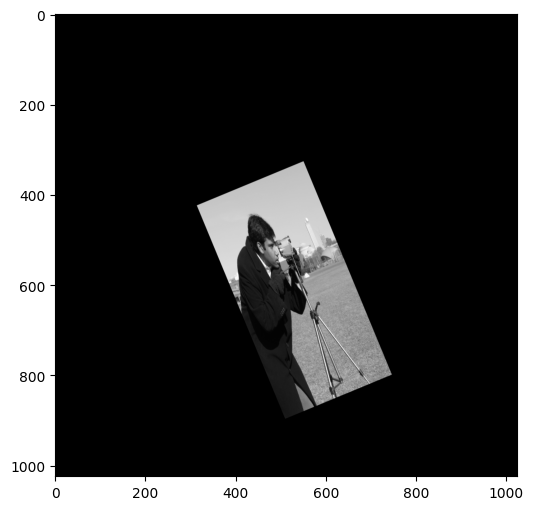

In [11]:
_=plot_grayscale(transform.warp(camera_image_background, transform_matrix))
plt.show()

> Q4. Is the transformation of the photograper image consistent with the geometric image and is this expected?      
> **End of exercise.**  

> **Answer:**     Yes. The transformation of the image of the photographer behaves like the rectangle and circle shape, as it follows the same scaling rule, affecting all the dimensions and the translation. The effect is seen like the second image of the above exercise.

> **Exercise 10-3:** One can use negative scaling with a similarity transform to create flipped images about an axis, e.g. mirror images. This appraoch can be quite useful in creating augmented datasets, and can be combined with rotaion, scaling, etc. to create additonal training examples. You will now complete the code in the cell below to display three cases:
> 1. Flip around the vertical axis with no rotation and maintaining scale.
> 2. Flip around the horizontal axis with no rotation and maintaining scale.
> 3. Flip around both axes with no rotation and maintaining scale.      

[[-1.000e+00  0.000e+00  1.024e+03]
 [ 0.000e+00  1.000e+00  0.000e+00]
 [ 0.000e+00  0.000e+00  1.000e+00]]
[[ 1.000e+00  0.000e+00  0.000e+00]
 [ 0.000e+00 -1.000e+00  1.024e+03]
 [ 0.000e+00  0.000e+00  1.000e+00]]
[[-1.000e+00  0.000e+00  1.024e+03]
 [ 0.000e+00 -1.000e+00  1.024e+03]
 [ 0.000e+00  0.000e+00  1.000e+00]]


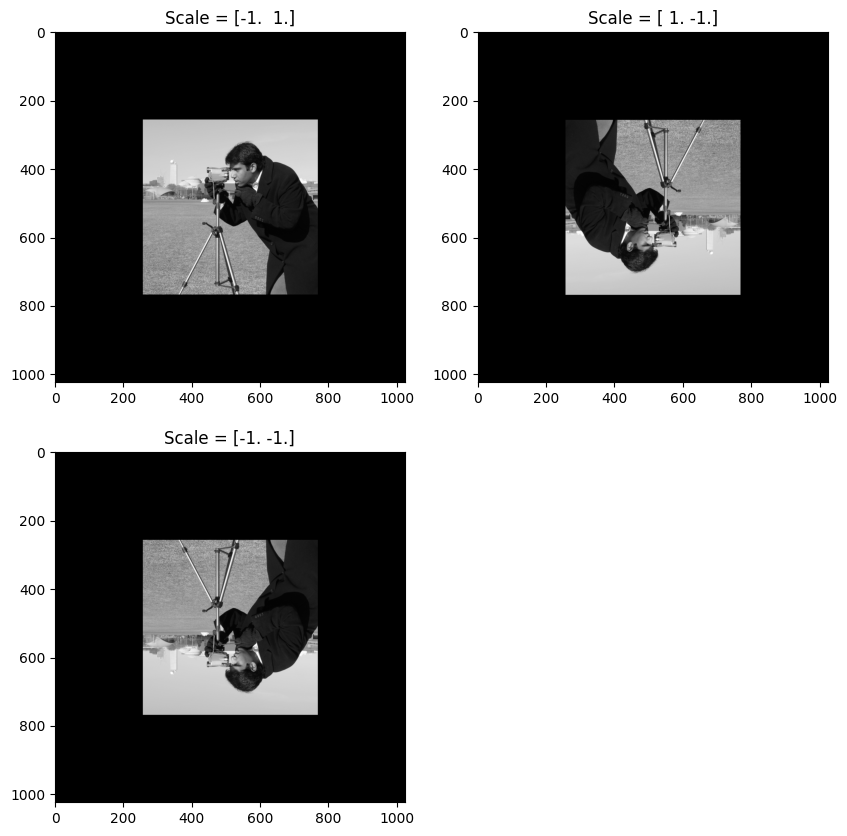

In [12]:
translate = np.array([[-1024, 0],[0, -1024],[-1024, -1024]])
## Complete the code required to create mirror image
scale = np.array([
    [-1.0,  1.0],
    [ 1.0, -1.0],
    [-1.0, -1.0]
])
_, ax = plt.subplots(2,2, figsize=(10, 10))
ax = ax.flatten()
ax[-1].set_visible(False)
for i, ax_i in enumerate(ax[:-1]):
    transform_matrix = similarity(0.0, translate[i,:], scale[i,:])
    print(np.round(transform_matrix,3))
    _=plot_grayscale(transform.warp(camera_image_background, transform_matrix), ax=ax_i)
    ax[i].set_title('Scale = ' + str(np.round(scale[i,:], 3)))
plt.show()

> **End of Exercise**

## Affine Transform

Continuing to generalize the transformation you will now add a shear factor to the transformation. An affine transformation can perform rotation, translation, scaling and shear. The affine transformation preserves parallel lines.   

> **Exercise 10-4:**  You will now do the following to explore the properties of the affine transform following these steps
> 1. Complete the `affine`function in the cell below to compute and return the following.      
>    a. Use the `similarity` function you created in Exercise 2 to compute the $3 x 3$ similarity transformation matrix.       
>    b. Create a $3 x 3$ shear transform as a Numpy array with $tan(\gamma)$ on the first two off-diagonal elements.
>    c. Use [numpy.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) function to multiply the similarity matrix (second argument) by the shear matrix (first argument). The order of the multiplication will mater.
> 2. Execute the code in the cell below.    

[[ 2.0e+00  0.0e+00 -8.0e+02]
 [ 2.0e+00  2.0e+00 -1.6e+03]
 [ 0.0e+00  0.0e+00  1.0e+00]]
[[ 2.0e+00  2.0e+00 -1.6e+03]
 [ 0.0e+00  2.0e+00 -8.0e+02]
 [ 0.0e+00  0.0e+00  1.0e+00]]


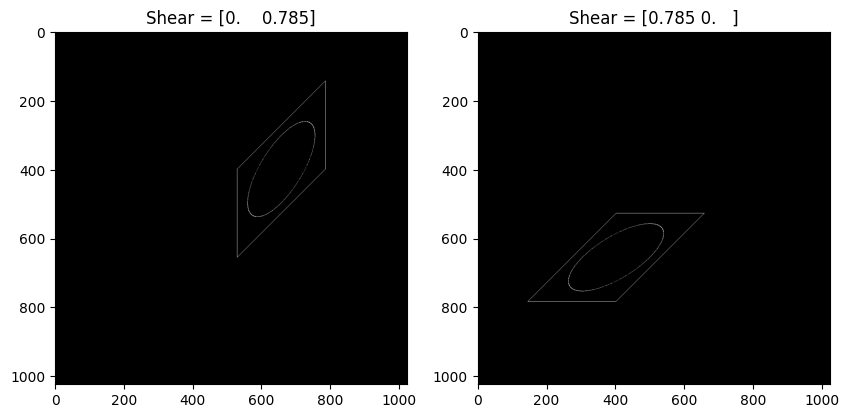

In [13]:
## Put your code below
def affine(theta, translation, scale, shear):
  Sim = similarity(theta, translation, scale)
  Sh = np.array([
      [1.0, math.tan(shear[0]), 0.0],
      [math.tan(shear[1]), 1.0, 0.0],
      [0.0, 0.0, 1.0]], dtype=float)
  return np.dot(Sh, Sim)

theta = 0.0
scale = [0.5,0.5]
translation = [-400,-400]

_, ax = plt.subplots(1,2, figsize=(10, 5))
ax = ax.flatten()
shear = np.array([[0.0, math.pi/4], [math.pi/4, 0.0]])
for i,ax_i in enumerate(ax):
    transform_matrix = affine(theta, translation, scale, shear[i,:])
    print(np.round(transform_matrix,3))
    _=plot_grayscale(transform.warp(synthetic_image, transform_matrix), ax=ax_i)
    ax_i.set_title('Shear = ' + str(np.round(shear[i,:], 3)))
plt.show()

> Examine these results and anser the following questions.     
> Q1. Examine the shear applied to rectangle. Are the shapes as expected from the shear applied and why?     
> Q2. What properties of the rectangle have been preserved by these transformations?      

> **Answers:**      
> Q1.    The shear applied to the rectangle makes it tilt on one direction in the same proportion tot he other direction. This makes the image to be tilted, transforming the rectangle in a parallelogram. The parallel lines continue, but both the angles and the distances to the vertices change on the form, as the shear is applied.\
>
> Q2.    As mentioned, the parallel lines are kept intact, but both angles and one distance (x or y) is warped depending if the shear is applied to the x or y axis.

> 3. Apply the second affine transform matrix to the photograph of the photographer and display the result.   

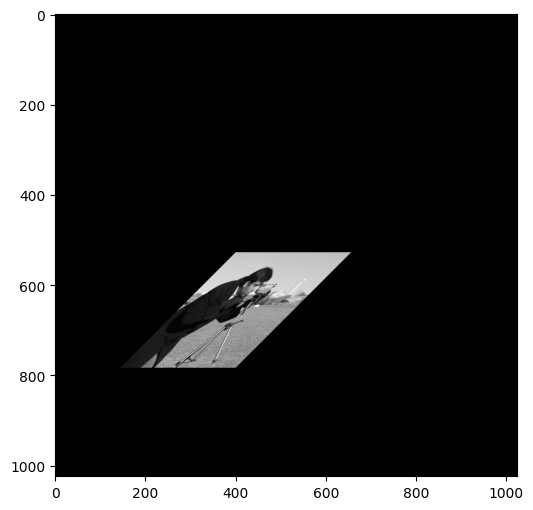

In [14]:
_=plot_grayscale(transform.warp(camera_image_background, transform_matrix))
plt.show()

> **End of Exercise**

## Working with the Intrinsic Matrix

Up until now, you have been working only with the **extrinsic transformation matrix**, which defines the projection from one plan onto another plane, with the same camera center. The extrinsic properties of are also known as **camera pose**. These transformations do not account for inernal camera parameters.   

The **intrinsic matrix** is used to model camera specific characteristics. Here we will only deal with one camera parameter, the focal length. Focal length is typically denoted $[f_x, f_y]$, for the x and y components, which can be independent. The differences in x and y can arrise for a number of reasons, such as asymmetry of the camera sensor.     

It is often easier to work with the inverse of focal length:     

$$\Bigg[\frac{1}{f_x},\frac{1}{f_x} \Bigg] = [\phi_x, \phi_y]$$    

In Cartesian coordinates, for a basic pinhole camera the object location, $[x,y,w]$, maps to the $[x,y]$ location on the image plane by the following relationships:   

$$[x,y] = \Bigg[\frac{u}{f_x\ w},\frac{v}{f_x\ w} \Bigg]= \Bigg[\frac{\phi_x\ u}{w},\frac{\phi_y\ v}{w} \Bigg]$$


> **Exercise 10-5:** You will now apply an intrinsic matrix for two different camera focal lengths by the following steps:  
> 1. Define a Numpy intrinsic matrix in homogeneous coordinates with focal length $[f_x, f_y]=[0.5, 0.5]$, array offset of 0, and skew correction of 0.      
> 2. Define a Numpy extrinsic transform matrix in homogeneous coordinates using the `affine` function you created in Exercise 3 with rotation $\theta= 0$, translation $= [-512,-512]$, scaling $=[1.0,1.0]$, and shear $[0.0,0.0]$.  
> 3. Perform matrix multiplication between the extrinsic matrix (first argument) by the intrinsic matrix (second argument) using [numpy.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html).
> 4. Print the resulting product of the transformation matrices.
> 5. Apply the resulting transformation product to the image of the photographer and display the result.

[[   2.    0. -512.]
 [   0.    2. -512.]
 [   0.    0.    1.]]


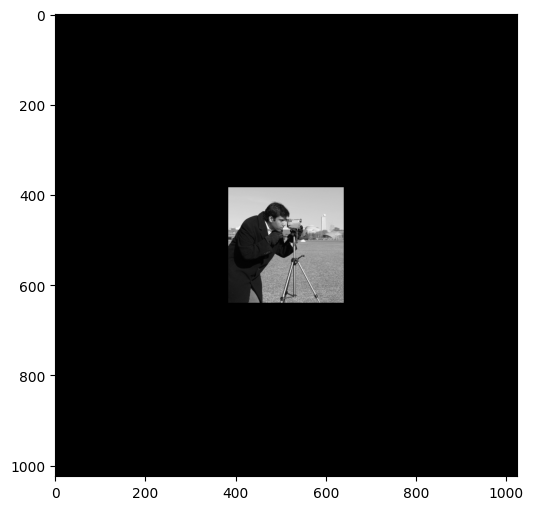

In [15]:
## Put your code below

K1 = np.array([
    [2.0, 0.0, 0.0],
    [0.0, 2.0, 0.0],
    [0.0, 0.0, 1.0]
], dtype=float)

E1 = affine(theta=0.0, translation=[-512, -512],
            scale=[1.0, 1.0], shear=[0.0, 0.0])

transform_matrix = np.dot(E1, K1)

print(transform_matrix)

_=plot_grayscale(transform.warp(camera_image_background, transform_matrix))
plt.show()

> 6. Define a Numpy intrinsic matrix in homogeneous coordinates with inverse focal length $[f_x, f_y]=[2.0, 2.0]$, array offset of 0, and skew correction of 0.     
> 7. Define a Numpy extrinsic transform matrix in homogeneous coordinates using the `affine` function you created in Exercise 3 with rotation $\theta= 0$, translation $= [256,256]$, scaling $=[1.0,1.0]$, and shear $[0.0,0.0]$.  
> 8. Perform matrix multiplication between the extrinsic matrix (first argument) by the intrinsic matrix (second argument) using [numpy.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html).
> 9. Print the resulting product of the transformation matrices.
> 10. Apply the resulting transformation product to the image of the photographer and display the result.

[[  2.   0. 256.]
 [  0.   2. 256.]
 [  0.   0.   1.]]


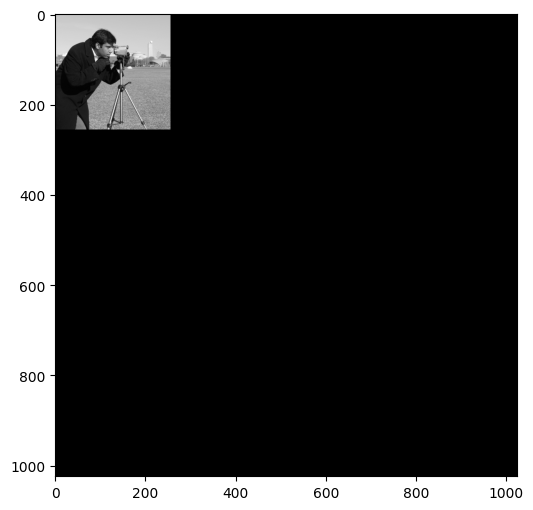

In [16]:
## Put your code below

K2 = np.array([
    [2.0, 0.0, 0.0],
    [0.0, 2.0, 0.0],
    [0.0, 0.0, 1.0]
], dtype=float)

E2 = affine(theta=0.0, translation=[256, 256],
            scale=[1.0, 1.0], shear=[0.0, 0.0])

transform_matrix = np.dot(E2, K2)


print(transform_matrix)

_=plot_grayscale(transform.warp(camera_image_background, transform_matrix))
plt.show()

> In one or two sentences expain the relationship you observe between focal length and field of view on the image plane and how do you think this effect relates to wide angle and telephoto camera lenses?       
> **End of exercise**.

> **Answers:**   We can see that as the focal lenght increases, there is a inverse and proportional effect, making the image to decrease, and vice-versa. in the case above, since the focal lenght is multiplied by 2, then the effect is like it has a zoom out of the image.

## Projective transform

All of the transforms we have worked on so far require the optical center to be at the same location. In other words, the perspective point is unchanged. Projective transforms are the most general planar transformations. Here we will only deal with some simple examples, planar transformations that are equivalent to changing the camera position or perspective point. This transformation or homography, $mathcal{H}$, can be expressed:    

$$\mathcal{H} = H_P H_A H_S H_E$$    
Where,        
$H_E =$ the Euclidean transform matrix.      
$H_S =$ the similarity transform matrix.    
$H_A =$ the affine transform matrix.    

For the planar case, we will formulate the projective transform, $H_P$, to incorporate two additional degrees of freedom,       
- $\theta_x$, rotation about the $x$ axis, and
- $\theta_y$, rotation about the $y$ axis.      
$$H_P = \begin{bmatrix}
   1  & 0 & 0 \\
    0  & cos(\theta_x) & sin(\theta_x) \\
    0  & -sin(\theta_x) & cos(\theta_x)
\end{bmatrix}
\begin{bmatrix}
   cos(\theta_y)  & 0 & -sin(\theta_y) \\
    0  & 1 & 0 \\
    sin(\theta_y)  & 0 & cos(\theta_y)
\end{bmatrix}
$$
$$
=
\begin{bmatrix}
   cos(\theta_y)  & 0 & -sin(\theta_y) \\
    sin(\theta_x) sin(\theta_y)  & cos(\theta_x) & sin(\theta_x) cos(\theta_y) \\
    cos(\theta_x) sin(\theta_y)  & -sin(\theta_x) & cos(\theta_x) cos(\theta_y)
\end{bmatrix}
$$

For the following exercise you will work with a picture of a piece of furniture in the interior of a house. To load and prepare this image execute the code in the cell below.  

**OBSERVATION: I could not run the code that was here and even if I tried to apply some of the suggestions in Ed, (like using all caps dwon letters for the name of the file), it didn't work.

In that sense I decided to look for the Building 4 mage and manually open the image of a "building4.jpg" I found in prof. Elston's github repository.

From the perspective of the exercise, I don't believe it changed the end result. Here is the error that I could not overcome:

UnidentifiedImageError                    

Traceback (most recent call last)

/tmp/ipykernel_463/1988185284.py in <cell line: 0>()
      5
      6 response = requests.get(url)
----> 7 building = Image.open(BytesIO(response.content))
      8 building = np.array(building)
      9 print('Iinital image shape = ' + str(building.shape))
    
/usr/local/lib/python3.12/dist-packages/PIL/Image.py in open(fp, mode, formats)
   3578         warnings.warn(message)
   3579     msg = "cannot identify image file %r" % (filename if filename else fp)
-> 3580     raise UnidentifiedImageError(msg)
   3581
   3582
   
UnidentifiedImageError: cannot identify image file <_io.BytesIO object at 0x7e4ce67799e0>

In [17]:
import os
print(os.getcwd())

/content


Response status code: 200
Initial image shape = (3024, 4032, 3)
Final image shape = (300, 400)


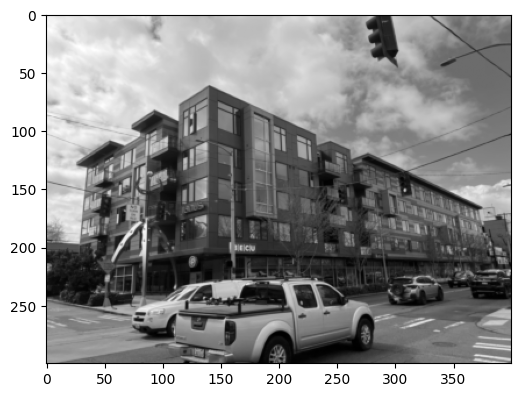

In [20]:
import requests
from io import BytesIO

url = "https://raw.githubusercontent.com/StephenElston/CSCI-E25/master/datafiles/Building4.jpg"

response = requests.get(url)
print('Response status code:', response.status_code)  # should print 200

building = Image.open(BytesIO(response.content))
building = np.array(building)
print('Initial image shape = ' + str(building.shape))

building = rgb2gray(building)
building = transform.resize(building, (300, 400))
print('Final image shape = ' + str(building.shape))

plot_grayscale(building)
plt.show()

> **Exercise 10-6:**  You will now do the following to explore the properties of the projective transform or homography following these steps
> 1. Complete the `projective`function in the cell below to compute and return the following using a vector $theta = [\theta_x, \theta_y, \theta_z]$ as an argument.      
>    a. Compute the $3 \times 3$ $H_P$ matrix using $\theta_y$ and $\theta_z$ as arguments.       
>    b. Compute the $3 \times 3$ affine transform using the translation, scale, and shear vectors as arguments.    
>    c. Use [numpy.dot](https://numpy.org/doc/stable/reference/generated/numpy.dot.html) function to multiply the perspective matrix (first argument) by the affine matrix (second argument). The order of the multiplication maters.
> 2. Execute the code in the cell below and examine the results.     

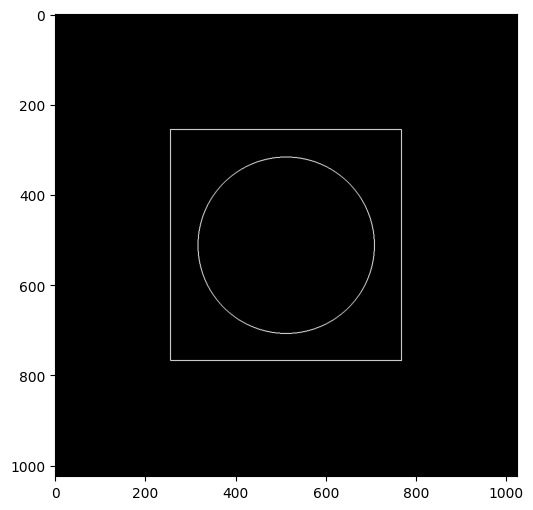

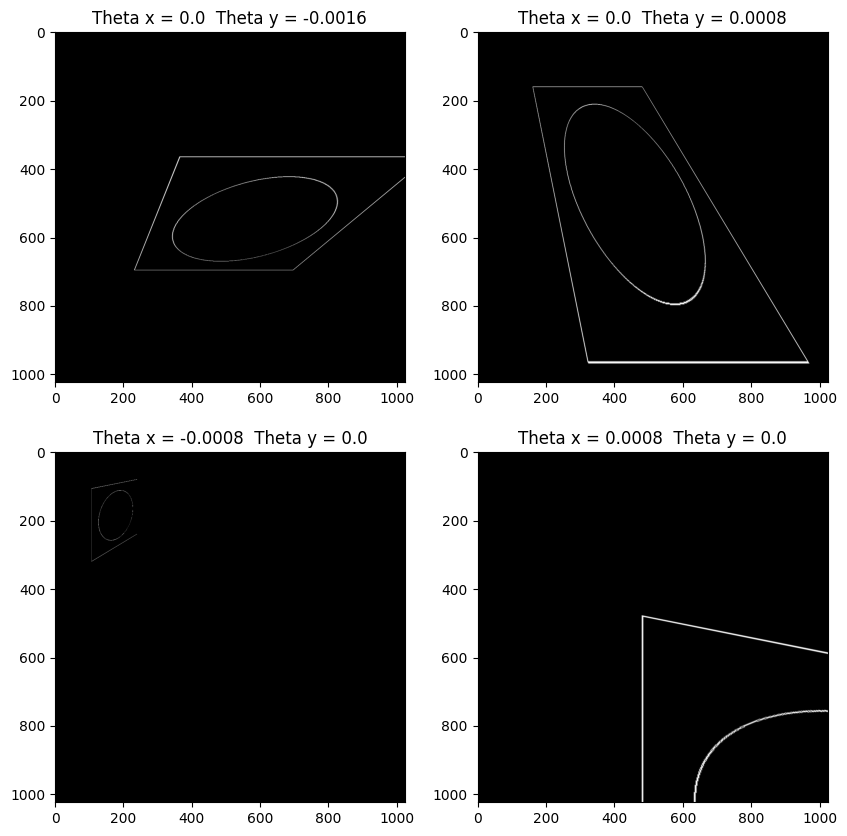

In [25]:
def projective(theta, translation, scale, shear):
    HP = np.array([
        [1.0,      0.0,      0.0],
        [0.0,      1.0,      0.0],
        [theta[0], theta[1], 1.0]
    ], dtype=float)

    A = affine(0.0, translation, scale, shear)
    return np.dot(HP, A)

plot_grayscale(synthetic_image)
plt.show()

shear = [0.0, 0.0]
theta = np.array([[0, -math.pi/2000.0, 0.0],
        [0, math.pi/4000.0, 0.0],
        [-math.pi/4000.0, 0.0, 0.0],
        [math.pi/4000.0, 0.0, 0.0]])
scale = np.array([[2.0, 2.0],
        [0.5, 0.5],
        [0.5, 0.5],
        [1.5, 1.5]])
translation = [0.0,0.0]

_, ax = plt.subplots(2,2, figsize=(10,10))
for i,ax_i in enumerate(ax.flatten()):
    transform_matrix = projective(theta[i,:], translation, scale[i,:], shear)
    _=plot_grayscale(transform.warp(synthetic_image, transform_matrix), ax=ax_i)
    ax_i.set_title('Theta x = ' + str(round(theta[i,0],4)) +
                   '  Theta y = ' + str(round(theta[i,1],4)))
plt.show()

> Examine the transformed images of the geometric shapes. The original geometric image has the perspective point on a line perpendicular to the center point. Based on the parameters of the projection provide a short answer to the following questions.
> 1. When a projective transform is applied to these images, what aspect of the original image is preserved?
> 2. In general (or relative) terms, describe how the camera center (perspective point) has moved for each of the four transforms applied to the original image.     
>     i. $[\theta_x = 0.0, \theta_y=-0.0016]$    
>    ii. $[\theta_x = 0.0, \theta_y=0.0008]$    
>    iii. $[\theta_x =-0.0008 , \theta_y=0.0]$     
>    iv. $[\theta_x =0.0008 , \theta_y=0.0]$    
> 3. Where are the vertical and horizontal vanishing points in the original image and why?
> 4. For each of the transformed images briefly indicate briefly explain in general (relative) terms where the vertical and horizontal vanishing points are and why?     
>     i. $[\theta_x = 0.0, \theta_y=-0.0016]$    
>    ii. $[\theta_x = 0.0, \theta_y=0.0008]$    
>    iii. $[\theta_x =-0.0008 , \theta_y=0.0]$     
>    iv. $[\theta_x =0.0008 , \theta_y=0.0]$       

> **Answers:**
> 1.   When the the projective() function transformation is applied, the general appearance of the image is preserved. The main strainght lines are preserved, even though there are different projections of the image, like zoom in and out and perspective changes (like if it is seen from an angle of perspective).
> 2.    
>     i. $[\theta_x = 0.0, \theta_y=-0.0016]$ : the y change affects a horizontal perspective effect, almost as if the camera has moved to one side, causing a perspective effect with the tilting of the image.    
>    ii. $[\theta_x = 0.0, \theta_y=0.0008]$ : The y-change is of the opposite direction as the first image, which makes the image to tilt to the other direction( as if the camera has moved to the other side, inverting the perspective.    
>    iii. $[\theta_x =-0.0008 , \theta_y=0.0]$ : The x-axis chnge now is now changing on the vertical perspective, moving it up and down. In this case, as it is negative, it goes to the origin of the image, on the left-top corner, which can be seen as the direction of the vanishing point.
>    iv. $[\theta_x =0.0008 , \theta_y=0.0]$ : The effect is opposed to the previous one (item iii), awhich means that the effect is like we approximate the camera to the object, using the vanishing point as reference.
> 3.  Tehre is no vanishing point in the original image, as parallel lines goes to infinity. So, infinity is the vanishing point for it, both vertically as horizontally.
> 4.     
>     i. $[\theta_x = 0.0, \theta_y=-0.0016]$ : AS the  image is tilted to the right, the vanishing point is on the right of the image, at a finite point a little outside of the image.  The vertical is infinity, as the vertical lines are parallel.          
>    ii. $[\theta_x = 0.0, \theta_y=0.0008]$  : As the image is tilted to the left, the vanishing point is a little to the left of the image, where the lines meet. The vertical is again in infinity.        
>    iii. $[\theta_x =-0.0008 , \theta_y=0.0]$ :  it looks like he image is zoomed out. It seems that the vanishing point is something around at or above the reference point of the image.
>    iv. $[\theta_x =0.0008 , \theta_y=0.0]$  : in this situation, it looks like the image is zoomed in, so he vanishing point seems to be below the image space

Next execute the code in the cell below to apply the perspective transform to the building image.   

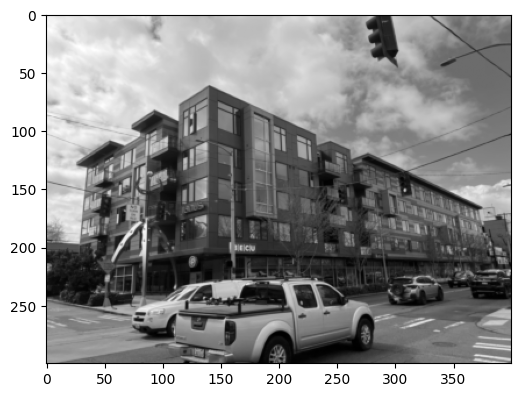

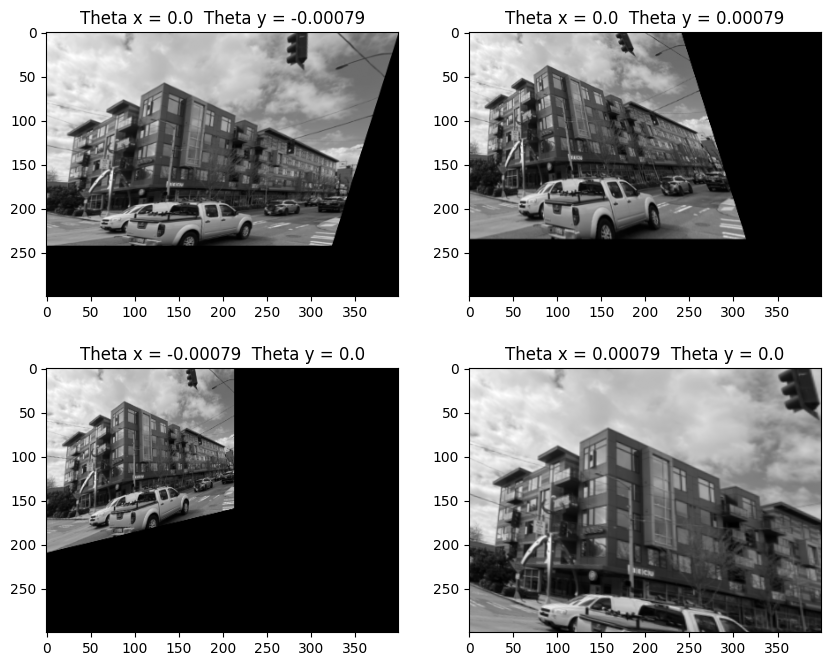

In [26]:
plot_grayscale(building)
plt.show()

shear = [0.0, 0.0]
theta = np.array([[0, -math.pi/4000.0, 0.0],
        [0, math.pi/4000.0, 0.0],
        [-math.pi/4000.0, 0.0, 0.0],
        [math.pi/4000.0, 0.0, 0.0]])
scale = np.array([[1.0, 1.0],
        [0.6, 0.6],
        [0.7, 0.7],
        [1.0, 1.0]])
translation = [0.0,0.0]

_, ax = plt.subplots(2,2, figsize=(10,8))
for i,ax_i in enumerate(ax.flatten()):
    transform_matrix = projective(theta[i,:], translation, scale[i,:], shear)
    _=plot_grayscale(transform.warp(building, transform_matrix), ax=ax_i)
    ax_i.set_title('Theta x = ' + str(round(theta[i,0],5)) +
                   '  Theta y = ' + str(round(theta[i,1],5)))
plt.show()

> **Exercise 10-7:** Examine these results, noting how the camera perspective point has been transformed. Given the distances to the objects in the image, in one or two sentences, explain why a planar transformation is a approximation for actually changing the camera pose.         

> **Answer:**   Similar to the previous exercise, the value os the theta is directing the perspective to the image, making it appear that the camera pose is being moved. As the vanishing points are  non-infinity (i.e., the sides of the image are not parallel), the distortion gives the impression that the camera is being moved an therefore there is some changes in the perspective of the viewer.

####  Copyright 2022, 2023, 2024, 2025, 2026 Stephen F Elston. All rights reserved.